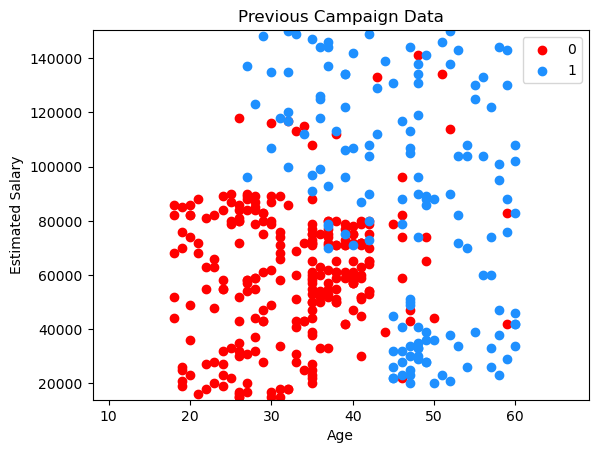

In [16]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import ListedColormap
from matplotlib.axes._axes import _log as matplotlib_axes_logger

# Load the dataset
dataset = pd.read_csv('E:\\ml\\Social_Network_Ads.csv')


dataset['Age'] = pd.to_numeric(dataset['Age'], errors='coerce')
dataset['EstimatedSalary'] = pd.to_numeric(dataset['EstimatedSalary'], errors='coerce')

# Drop rows with invalid values if any
dataset.dropna(inplace=True)

x = dataset[['Age', 'EstimatedSalary']].values
y = dataset['Purchased'].values


# Plot the Dataset
matplotlib_axes_logger.setLevel('ERROR')
X_set, y_set = x, y

# Create a grid

x_step = max(1, (X_set[:,0].max() - X_set[:,0].min()) / 200)     # ~200 points on X-axis
y_step = max(100, (X_set[:,1].max() - X_set[:,1].min()) / 200)   # ~200 points on Y-axis

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 10, stop=X_set[:, 0].max() + 10, step=x_step),
    np.arange(start=X_set[:, 1].min() - 1000, stop=X_set[:, 1].max() + 1000, step=y_step)
)

# Set axis limits
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

cmap = ListedColormap(('red', 'dodgerblue'))
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                color=cmap.colors[i], label=j)


# Titles and labels
plt.title('Previous Campaign Data')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()


In [2]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [3]:
X2

array([[ 14000.  ,  14000.  ,  14000.  , ...,  14000.  ,  14000.  ,
         14000.  ],
       [ 14000.25,  14000.25,  14000.25, ...,  14000.25,  14000.25,
         14000.25],
       [ 14000.5 ,  14000.5 ,  14000.5 , ...,  14000.5 ,  14000.5 ,
         14000.5 ],
       ...,
       [150999.25, 150999.25, 150999.25, ..., 150999.25, 150999.25,
        150999.25],
       [150999.5 , 150999.5 , 150999.5 , ..., 150999.5 , 150999.5 ,
        150999.5 ],
       [150999.75, 150999.75, 150999.75, ..., 150999.75, 150999.75,
        150999.75]])

In [4]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_sc = sc.fit_transform(x)

In [5]:
#training logistic regreesion model
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state=0)
classifier.fit(X_sc,y)

LogisticRegression(random_state=0)

In [ ]:
Anything above blue linemeans the person will purchase it and below it will not purchase it 
although there are some mismatches but no model is perfect 

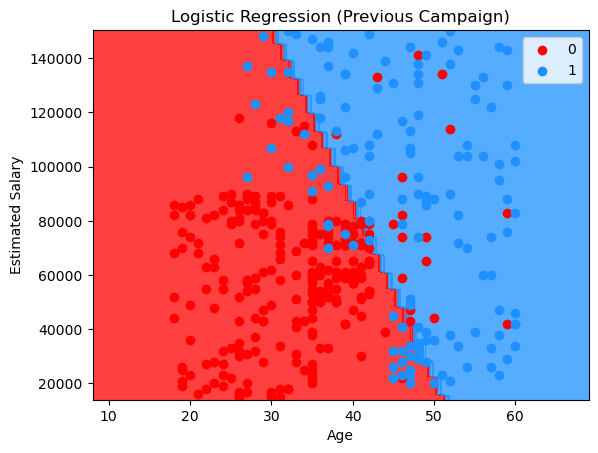

In [15]:
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt

X_set , y_set = sc.inverse_transform(X_sc), y
#Auto-tune step based on range
x_step = max(1, (X_set[:,0].max() - X_set[:,0].min()) / 200)     # ~200 points on X-axis
y_step = max(100, (X_set[:,1].max() - X_set[:,1].min()) / 200)   # ~200 points on Y-axis

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 10, stop=X_set[:, 0].max() + 10, step=x_step),
    np.arange(start=X_set[:, 1].min() - 1000, stop=X_set[:, 1].max() + 1000, step=y_step)
)

cmap = ListedColormap(["red", "dodgerblue"])   # ✅ keep as colormap object

Z = classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T))
Z = Z.reshape(X1.shape)

plt.contourf(X1, X2, Z, alpha=0.75, cmap=cmap)   # ✅ use cmap directly
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# scatter points
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        c=[cmap(i)],         # ✅ use cmap(i) for color
        label=j
    )

plt.title('Logistic Regression (Previous Campaign)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()


X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 10, stop=X_set[:, 0].max() + 10, step=0.25),
    np.arange(start=X_set[:, 1].min() - 1000, stop=X_set[:, 1].max() + 1000, step=0.25)
)
The Age axis (X_set[:,0]) is fine, maybe ~30–60 range → ~200 points.

The Estimated Salary axis (X_set[:,1]) spans thousands → with step 0.25 it explodes into hundreds of millions of points.

That’s why NumPy tries to allocate a 2 GB array → and crashes.


When we plot decision boundaries with a meshgrid, the step size controls how many grid points get generated.

Suppose feature x ranges from 20 to 60 → range = 40.
If we divide by 200 → step ≈ 0.2 → about 200 points along that axis.

Suppose feature y ranges from 20,000 to 80,000 → range = 60,000.
If we divide by 200 → step ≈ 300 → about 200 points along that axis.

So 200 is arbitrary but chosen to keep the grid at a reasonable resolution (~200 × 200 = 40k points total), which is memory-safe and still smooth enough to draw contours.

General rule of thumb

If you want a higher-resolution plot → divide by 300 or 400.

If you want a faster/lighter plot → divide by 100.

The idea is to cap the grid size to a few tens of thousands of points, not hundreds of millions.

In [8]:
import matplotlib
print(matplotlib.__version__)


3.8.0


In [10]:
print(ListedColormap)


<class 'matplotlib.colors.ListedColormap'>


In [11]:
Z = classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T))
print(np.unique(Z))


[0 1]
